In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from driver_genes.viutils import get_palette, adjust_color

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
sns.set_theme(style="ticks")

## obtain predicted probabilities for each cell

In [23]:
label_metrics_df = pd.read_pickle('data/schmidt_label_metrics_df.pkl')
distance_df = pd.read_pickle('data/schmidt_distance_df.pkl')

In [24]:
label_metrics_df['method'].value_counts()

method
CPA         138
CellNavi    138
DEG         138
GEARS       138
Ours        138
Name: count, dtype: int64

In [25]:
plot_df = pd.merge(
    label_metrics_df, distance_df, 
    on=['cell_type', 'perturbation'],
    how='left'
)
plot_df


/tmp/ipykernel_1027512/3555343458.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  plot_df = pd.merge(


cell_type method perturbation       auc              relpos  \
                                            mean       std      mean   
0    Re-stimulated    CPA       ABCB10  0.570268  0.038526  0.730899   
1    Re-stimulated    CPA       AKAP12  0.436179  0.022437  0.178435   
2    Re-stimulated    CPA         ALX4  0.477314  0.018935  0.392870   
3    Re-stimulated    CPA     APOBEC3C  0.406364  0.026038  0.665623   
4    Re-stimulated    CPA     APOBEC3D  0.419661  0.038156  0.701333   
..             ...    ...          ...       ...       ...       ...   
685        Resting   Ours      TNFRSF9  0.792787  0.021266  0.843304   
686        Resting   Ours     TRAF3IP2  0.828332  0.053083  0.870609   
687        Resting   Ours       TRIM21  0.714681  0.021880  0.873797   
688        Resting   Ours         VAV1  0.778823  0.020483  0.735768   
689        Resting   Ours          WT1  0.905643  0.021461  0.930029   

              top1acc           top5recall            distance            
          std    mean       std       mean       std      mean       std  
0    0.012429   0.008  0.010954      0.064  0.021909  0.455849  0.053009  
1    0.040287   0.000  0.000000      0.040  0.024495  0.397815  0.081431  
2    0.024132   0.000  0.000000      0.000  0.000000  0.590052  0.140982  
3    0.022644   0.012  0.010954      0.052  0.030332  0.770958  0.180398  
4    0.038828   0.096  0.008944      0.576  0.058992  0.902861  0.107104  
..        ...     ...       ...        ...       ...       ...       ...  
685  0.018380   0.288  0.036332      0.456  0.076681  0.459785  0.085925  
686  0.038290   0.396  0.084143      0.604  0.065422  1.161419  0.494322  
687  0.010061   0.216  0.026077      0.524  0.038471  0.388526  0.044252  
688  0.030410   0.096  0.035777      0.280  0.054772  1.097638  0.272181  
689  0.013113   0.696  0.047749      0.796  0.040988  1.073121  0.312364  

[690 rows x 13 columns]

In [26]:
hue_order=['Ours', 'CellNavi', 'GEARS', 'CPA', 'DEG'][::-1]
colors_sel = get_palette('benchmark').colors[::-1]
colors_sel_light = list(map(lambda x: adjust_color(x, l_factor=1.3), colors_sel))

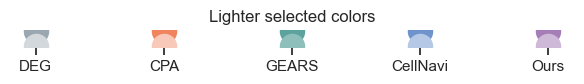

In [27]:
plt.figure(figsize=(6, 1))
for i, (color_m, color_l) in enumerate(zip(colors_sel, colors_sel_light)):
    plt.scatter(i, 1, color=color_m, s=300)
    plt.scatter(i, 0, color=color_l, s=300)
plt.xticks(range(len(colors_sel_light)), [h for h in hue_order])
plt.yticks([])
plt.title("Lighter selected colors")
plt.box(False)
plt.tight_layout()
plt.show()

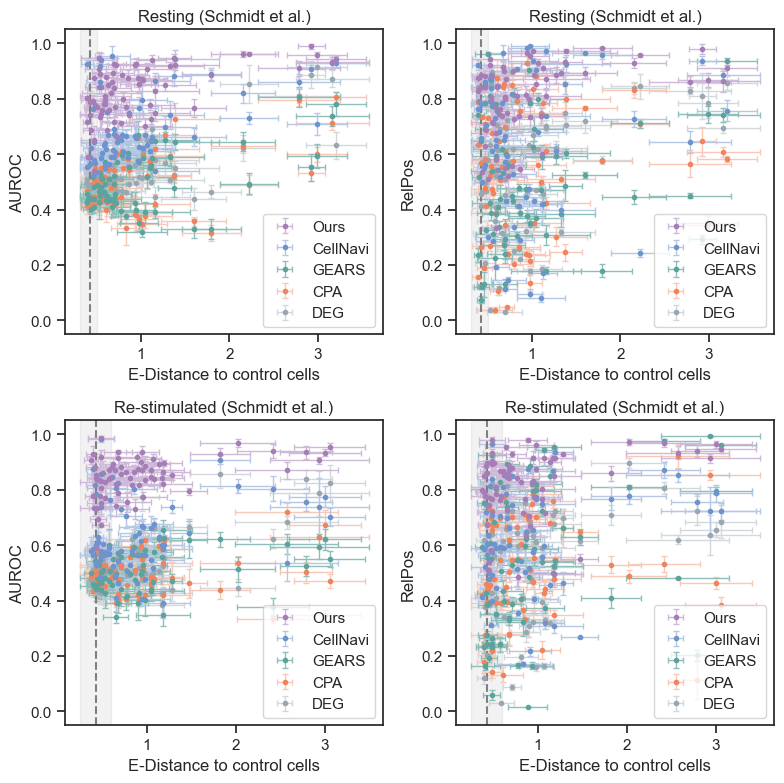

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for k, cell_type in enumerate(['Resting', 'Re-stimulated']):
    dist_mean = distance_df.loc[
        (distance_df['cell_type']==cell_type) & (distance_df['perturbation']=='control'), 
        ('distance', 'mean')
    ].values[0]
    dist_std = distance_df.loc[
        (distance_df['cell_type']==cell_type) & (distance_df['perturbation']=='control'), 
        ('distance', 'std')
    ].values[0]
    for j, metric in enumerate(['auc', 'relpos']):
        ax = axes[k, j]
        for i, method in enumerate(hue_order):
            subplot_df = plot_df.loc[(plot_df['cell_type']==cell_type) & (plot_df['method']==method)]
            ax.errorbar(
                x=subplot_df[('distance', 'mean')],
                xerr=subplot_df[('distance', 'std')],
                y=subplot_df[(metric, 'mean')],
                yerr=subplot_df[(metric, 'std')],
                fmt='o',
                capsize=2,
                capthick=1,
                elinewidth=1,
                markersize=3,
                color=colors_sel[i],
                ecolor=colors_sel_light[i],
                label=method,
            )
        ax.axvline(
            distance_df.loc[distance_df['perturbation'] == 'control', ('distance','mean')].values[0],
            color='gray',
            linestyle='--',
        )
        ax.axvspan(
            dist_mean - dist_std,
            dist_mean + dist_std,
            color='gray',
            alpha=0.1,
        )
        ax.set_ylim(-0.05,1.05)
        ax_handles, ax_labels = ax.get_legend_handles_labels()
        ax.legend(ax_handles[::-1], ax_labels[::-1], loc='lower right')
        ax.set_xlabel('E-Distance to control cells')
        if metric == 'auc':
            ax.set_ylabel('AUROC')
        else:
            ax.set_ylabel('RelPos')
        ax.set_title(f'{cell_type} (Schmidt et al.)')
fig.tight_layout()
fig.savefig('../figures/2_benchmarking_schmidt_auc_relpos.pdf')
fig.show()